Dataset prêt : (9537, 17)
Distribution des classes :
 attack_detected
0    5273
1    4264
Name: count, dtype: int64


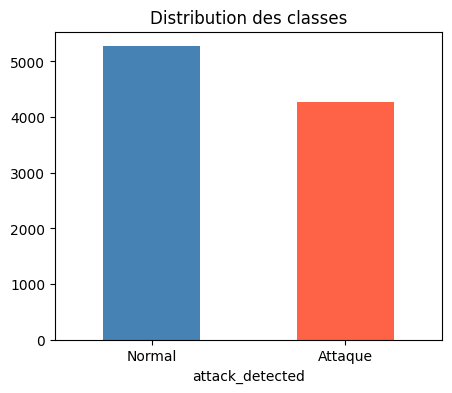

Visualisations sauvegardées.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/cybersecurity_intrusion_data.csv")

# Supprimer session_id (identifiant inutile)
df = df.drop(columns=['session_id'])

# Remplir les valeurs manquantes de encryption_used par "None"
df['encryption_used'] = df['encryption_used'].fillna('None')

# Encodage one-hot des colonnes catégorielles
df = pd.get_dummies(df, columns=['protocol_type', 'encryption_used', 'browser_type'])

# Séparer features et cible
X = df.drop(columns=['attack_detected'])
y = df['attack_detected']

# Normaliser les colonnes numériques
num_cols = ['network_packet_size', 'login_attempts', 'session_duration',
            'ip_reputation_score', 'failed_logins']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Dataset prêt :", X.shape)
print("Distribution des classes :\n", y.value_counts())

# --- Visualisations EDA ---

# 1. Distribution de la cible
plt.figure(figsize=(5, 4))
y.value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Normal', 'Attaque'], rotation=0)
plt.title("Distribution des classes")
plt.savefig("../outputs/eda_classes.png", bbox_inches='tight')
plt.show()
plt.close()

# 2. Heatmap de corrélation (colonnes numériques seulement)
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['attack_detected']].corr(),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Corrélation entre les features numériques")
plt.savefig("../outputs/eda_heatmap.png", bbox_inches='tight')
plt.close()

# 3. Boxplot : failed_logins selon attaque ou non
plt.figure(figsize=(6, 4))
sns.boxplot(x='attack_detected', y='failed_logins', data=df)
plt.xticks([0, 1], ['Normal', 'Attaque'])
plt.title("Failed logins selon le type de session")
plt.savefig("../outputs/eda_boxplot.png", bbox_inches='tight')
plt.close()

print("Visualisations sauvegardées.")